# GeoClip Evaluation — Baseline vs Fine-Tuned

Compares the original pretrained GeoCLIP against the Italy fine-tuned model.

## What this notebook does
1. Loads the cleaned dataset from Drive and creates a held-out **test split**
2. Defines **sanity-check** images (famous Italian landmarks with known GPS)
3. Loads **Baseline GeoCLIP** (no fine-tuning)
4. Loads **Fine-Tuned GeoClipItaly** from a checkpoint
5. Runs inference with both models on the same test images
6. Produces **comparison charts**: error histogram, accuracy @ threshold, confusion matrix
7. Shows predictions on an **interactive map**
8. Runs **MC Dropout heatmap** for the fine-tuned model on a single image

## Run order (all cells, top to bottom)

| # | Cell | Notes |
|---|------|-------|
| 1 | Install | Every session |
| 2 | Config | Edit paths here if needed |
| 3 | Mount Drive | Every session |
| 4 | Load Dataset & Split | Creates test_df |
| 5 | Sanity Images | Loads hardcoded landmark metadata from local images |
| 6 | Model Classes | Defines architecture — must run before loading |
| 7 | Load Baseline | Loads original GeoCLIP |
| 8 | Load Fine-Tuned | Loads your checkpoint |
| 9 | Inference — Test Set | Runs both models (takes a few minutes) |
| 10 | Inference — Sanity | Quick sanity check on known landmarks |
| 11 | Charts | All comparison plots |
| 12 | Map | Interactive map |
| 13 | MC Dropout | Single-image heatmap for fine-tuned model |


In [ ]:
# Install all dependencies — run every session
!pip install -q geoclip pandas torch torchvision tqdm scikit-learn
!pip install -q folium seaborn matplotlib requests Pillow
print("✅ Packages installed.")


✅ Packages installed.


In [ ]:
# ============================================================
# GLOBAL CONFIGURATION — edit ONLY this cell
# ============================================================
import os

# --- Google Drive ---
DRIVE_BASE           = "/content/drive/MyDrive/Vision_Project_2026"
DRIVE_CHECKPOINT_DIR = f"{DRIVE_BASE}/checkpoints_v1"

# Dataset paths — must match GeoClip_Training.ipynb exactly
DRIVE_MASTER_CSV     = f"{DRIVE_BASE}/ItalyDataset/italy_master.csv"
DRIVE_ITALY_TARS_DIR = f"{DRIVE_BASE}/ItalyDataset/archives"

# Local extract dir (same as training)
LOCAL_EXTRACT_DIR = "/content/gld_images"
os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)

# Region filter — set to None to use all regions (must match training)
# Options: 'nord', 'centro', 'sud_isole'
TRAIN_REGIONS = None

# --- Italy bounding box — must match GeoClip_Training.ipynb exactly ---
MIN_LAT, MAX_LAT = 35.4, 47.2
MIN_LON, MAX_LON =  6.6, 18.8

# --- Data split — must match GeoClip_Training.ipynb exactly ---
TEST_SIZE   = 0.15
VAL_SIZE    = 0.15
RANDOM_SEED = 42

# --- Fine-tuned checkpoint ---
CHECKPOINT_FILENAME = "geoclip_italy_BEST.pth"
CHECKPOINT_PATH     = f"{DRIVE_CHECKPOINT_DIR}/{CHECKPOINT_FILENAME}"

# --- Inference settings ---
N_TEST_SAMPLES  = None  # None = use all test images; set an int to cap for speed
MC_DROPOUT_RUNS = 50    # Number of forward passes for MC Dropout

print("Configuration loaded.")
print(f"   Master CSV     : {DRIVE_MASTER_CSV}")
print(f"   Italy TARs dir : {DRIVE_ITALY_TARS_DIR}")
print(f"   Checkpoint     : {CHECKPOINT_PATH}")
print(f"   Train regions  : {TRAIN_REGIONS if TRAIN_REGIONS is not None else 'all'}")
print(f"   Test samples   : {N_TEST_SAMPLES if N_TEST_SAMPLES is not None else 'all'}")


In [ ]:
from google.colab import drive
import os, shutil

if os.path.exists('/content/drive') and os.path.ismount('/content/drive'):
    print("Drive already mounted. Unmounting...")
    drive.flush_and_unmount()

if os.path.exists('/content/drive') and os.listdir('/content/drive'):
    for item in os.listdir('/content/drive'):
        item_path = os.path.join('/content/drive', item)
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.unlink(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)


## 📂 Section 1: Load Dataset & Create Test Split

In [ ]:
import os
import tarfile
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ── Load master CSV (pre-filtered Italy dataset) ───────────────────────────────
print(f"Loading: {DRIVE_MASTER_CSV}")
raw_df = pd.read_csv(DRIVE_MASTER_CSV)
print(f"  Raw rows : {len(raw_df):,}")
print(f"  Columns  : {list(raw_df.columns)}")

raw_df['image_id'] = raw_df['image_id'].astype(str)
raw_df['lat']      = pd.to_numeric(raw_df['lat'], errors='coerce')
raw_df['lon']      = pd.to_numeric(raw_df['lon'], errors='coerce')

italy_df = raw_df.dropna(subset=['image_id', 'lat', 'lon', 'local_path']).copy()

if TRAIN_REGIONS is not None:
    before   = len(italy_df)
    italy_df = italy_df[italy_df['region'].isin(TRAIN_REGIONS)].reset_index(drop=True)
    print(f"  Region filter {TRAIN_REGIONS}: {before:,} -> {len(italy_df):,} rows")
else:
    italy_df = italy_df.reset_index(drop=True)

print(f"Ready rows : {len(italy_df):,}")

# ── Extract region TARs (skips already-extracted regions) ─────────────────────
def find_region_tar(region):
    p = os.path.join(DRIVE_ITALY_TARS_DIR, f'italy_{region}.tar')
    return p if os.path.exists(p) else None

def region_sample_exists(region):
    subset = italy_df[italy_df['region'] == region].head(3)
    for img_id in subset['image_id']:
        if os.path.exists(os.path.join(LOCAL_EXTRACT_DIR, f'{img_id}.jpg')):
            return True
    return False

def extract_region_tar(tar_path):
    size_mb = os.path.getsize(tar_path) / (1024 * 1024)
    print(f"  Extracting {os.path.basename(tar_path)} ({size_mb:.0f} MB) ...")
    with tarfile.open(tar_path, 'r') as tar:
        try:
            tar.extractall(path=LOCAL_EXTRACT_DIR, filter='data')
        except TypeError:
            tar.extractall(path=LOCAL_EXTRACT_DIR)

regions_needed = italy_df['region'].dropna().unique().tolist()
already_done, to_extract, no_tar = [], [], []
for region in regions_needed:
    if region_sample_exists(region):
        already_done.append(region)
    elif find_region_tar(region) is not None:
        to_extract.append(region)
    else:
        no_tar.append(region)

print(f"  Already extracted : {already_done}")
print(f"  Will extract now  : {to_extract}")
if no_tar:
    print(f"  TAR not found     : {no_tar}")

for region in tqdm(to_extract, desc='Extracting region TARs'):
    extract_region_tar(find_region_tar(region))

# ── Build image_id -> local path index ────────────────────────────────────────
image_index = {}
for img_id in italy_df['image_id']:
    path = os.path.join(LOCAL_EXTRACT_DIR, f'{img_id}.jpg')
    if os.path.exists(path):
        image_index[img_id] = path

found   = len(image_index)
missing = len(italy_df) - found
print(f"  Found   : {found:,} images ({found / max(len(italy_df), 1) * 100:.1f}%)")
print(f"  Missing : {missing:,}")

trainable_df = italy_df[italy_df['image_id'].isin(image_index)].copy()

# ── 3-way split — identical to GeoClip_Training.ipynb ─────────────────────────
# Step 1: carve out test set
temp_df, test_df  = train_test_split(trainable_df, test_size=TEST_SIZE,  random_state=RANDOM_SEED)
# Step 2: carve out val from the remainder (same as training)
train_df, val_df  = train_test_split(temp_df,      test_size=VAL_SIZE,   random_state=RANDOM_SEED)

print(f"\nSplit: train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")
print(f"  (Matches GeoClip_Training.ipynb split with seed={RANDOM_SEED})")

# Optional cap for quick runs
if N_TEST_SAMPLES is not None and len(test_df) > N_TEST_SAMPLES:
    test_df = test_df.sample(n=N_TEST_SAMPLES, random_state=RANDOM_SEED).copy()
    print(f"  Test capped to {N_TEST_SAMPLES} images")

print(f"\nEvaluating on {len(test_df):,} test images.")


Loading: /content/drive/MyDrive/Vision_Project_2026/ItalyDataset/italy_master.csv
  Raw rows : 34,183
  Columns  : ['image_id', 'local_path', 'lat', 'lon', 'region', 'shard', 'wiki_url', 'landmark_id', 'license', 'author', 'supercategory', 'natural_or_human_made', 'dataset']
Ready rows : 34,183
  Already extracted : []
  Will extract now  : ['nord', 'centro', 'sud_isole']


Extracting region TARs:   0%|          | 0/3 [00:00<?, ?it/s]

  Extracting italy_nord.tar (2288 MB) ...


Extracting region TARs:  33%|███▎      | 1/3 [01:01<02:03, 61.98s/it]

  Extracting italy_centro.tar (1148 MB) ...


Extracting region TARs:  67%|██████▋   | 2/3 [01:38<00:46, 46.79s/it]

  Extracting italy_sud_isole.tar (700 MB) ...


Extracting region TARs: 100%|██████████| 3/3 [01:59<00:00, 39.74s/it]

  Found   : 34,183 images (100.0%)
  Missing : 0

Split: train 24,696 | val 4,359 | test 5,128
  (Matches GeoClip_Training.ipynb split with seed=42)

Evaluating on 5,128 test images.


## 🏛️ Section 2: Sanity Check Images

Famous Italian landmarks with known GPS coordinates.
The notebook reads the images from a local directory and uses a hardcoded metadata manifest.
These images were NOT in your training set, so they give a fair external test.


In [ ]:
import os
from PIL import Image

# Local directory that contains the landmark images
SANITY_IMAGES_DIR = "/content/drive/MyDrive/Vision_Project_2026/sanity_images"
LOCAL_SANITY_DIR = "sanity_images"
os.makedirs(LOCAL_SANITY_DIR, exist_ok=True)

# Hardcoded metadata from the attached landmark table
SANITY_LANDMARKS = [
    {
        "name": "00003fe2469cdbf5",
        "image_id": "00003fe2469cdbf5",
        "file_path": "/content/google_landmark_images/0/0/0/00003fe2469cdbf5.jpg",
        "category": "Holy_Trinity_Church_(Hrastovlje)",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Holy_Trinity_Church_(Hrastovlje)",
        "lat": 45.509664923,
        "lon": 13.901854044,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "00011e1543c80df7",
        "image_id": "00011e1543c80df7",
        "file_path": "/content/google_landmark_images/0/0/0/00011e1543c80df7.jpg",
        "category": "C3%B8glise_Sainte-Rosalie_de_Tourette-Levens",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:%C3%B8glise_Sainte-Rosalie_de_Tourette-Levens",
        "lat": 43.786613,
        "lon": 7.276052,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "000172f4c9656a15",
        "image_id": "000172f4c9656a15",
        "file_path": "/content/google_landmark_images/0/0/0/000172f4c9656a15.jpg",
        "category": "Villa_Della_Porta_Bozzolo",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Villa_Della_Porta_Bozzolo",
        "lat": 45.906832,
        "lon": 8.712161,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "0002214e4407b9c0",
        "image_id": "0002214e4407b9c0",
        "file_path": "/content/google_landmark_images/0/0/0/0002214e4407b9c0.jpg",
        "category": "Obere_Schleuse",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Obere_Schleuse",
        "lat": 46.75646,
        "lon": 7.63249,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "000234836dba6876",
        "image_id": "000234836dba6876",
        "file_path": "/content/google_landmark_images/0/0/0/000234836dba6876.jpg",
        "category": "San_Donato_in_Polverosa",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:San_Donato_in_Polverosa",
        "lat": 43.79052,
        "lon": 11.22609,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "0002c554aee7bde0",
        "image_id": "0002c554aee7bde0",
        "file_path": "/content/google_landmark_images/0/0/0/0002c554aee7bde0.jpg",
        "category": "Rape_of_the_Sabine_Women_at_Loggia_dei_Lanzi",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Rape_of_the_Sabine_Women_at_Loggia_dei_Lanzi",
        "lat": 43.7693,
        "lon": 11.2555,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "0003e5d7546cae13",
        "image_id": "0003e5d7546cae13",
        "file_path": "/content/google_landmark_images/0/0/0/0003e5d7546cae13.jpg",
        "category": "Cathedral_(Brixen)",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Cathedral_(Brixen)",
        "lat": 46.715888,
        "lon": 11.657763,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "0004147d3dac1c90",
        "image_id": "0004147d3dac1c90",
        "file_path": "/content/google_landmark_images/0/0/0/0004147d3dac1c90.jpg",
        "category": "Sava",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Sava",
        "lat": 46.344230555556,
        "lon": 14.1554111111111,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "0004981de60ced7",
        "image_id": "0004981de60ced7",
        "file_path": "/content/google_landmark_images/0/0/0/00044981de60ced7.jpg",
        "category": "Sant'Ambrogio_(Uscio)",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Sant'Ambrogio_(Uscio)",
        "lat": 44.411,
        "lon": 9.1671,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
    {
        "name": "0004cf009bd107ac",
        "image_id": "0004cf009bd107ac",
        "file_path": "/content/google_landmark_images/0/0/0/0004cf009bd107ac.jpg",
        "category": "Borja_(mountain)",
        "wiki_url": "http://commons.wikimedia.org/wiki/Category:Borja_(mountain)",
        "lat": 44.53,
        "lon": 17.7,
        "status": "success",
        "dataset": "train",
        "shard": 0,
        "is_italy": True,
    },
]

print(f"📂 Loading {len(SANITY_LANDMARKS)} hardcoded sanity images from: {SANITY_IMAGES_DIR}")

sanity_data = []
missing_images = []

for landmark in SANITY_LANDMARKS:
    filename = os.path.basename(landmark["file_path"])
    source_path = os.path.join(SANITY_IMAGES_DIR, filename)
    local_path = os.path.join(LOCAL_SANITY_DIR, filename)

    if not os.path.exists(source_path):
        missing_images.append(source_path)
        print(f"   ❌ Missing: {source_path}")
        continue

    try:
        with Image.open(source_path) as img:
            img.verify()

        with Image.open(source_path) as img:
            img.convert("RGB").save(local_path)

        sanity_data.append({
            **landmark,
            "local_path": local_path,
            "source_path": source_path,
        })
        print(f"   ✅ Loaded: {landmark['image_id']} -> {landmark['category']}")
    except Exception as e:
        print(f"   ❌ Error with {landmark['image_id']}: {str(e)[:80]}")

print(f"\n✨ Done! {len(sanity_data)}/{len(SANITY_LANDMARKS)} sanity images ready.")
if missing_images:
    print("   Missing images:")
    for path in missing_images:
        print(f"   - {path}")

📂 Loading 10 hardcoded sanity images from: /content/drive/MyDrive/Vision_Project_2026/sanity_images
   ✅ Loaded: 00003fe2469cdbf5 -> Holy_Trinity_Church_(Hrastovlje)
   ✅ Loaded: 00011e1543c80df7 -> C3%B8glise_Sainte-Rosalie_de_Tourette-Levens
   ✅ Loaded: 000172f4c9656a15 -> Villa_Della_Porta_Bozzolo
   ✅ Loaded: 0002214e4407b9c0 -> Obere_Schleuse
   ✅ Loaded: 000234836dba6876 -> San_Donato_in_Polverosa
   ✅ Loaded: 0002c554aee7bde0 -> Rape_of_the_Sabine_Women_at_Loggia_dei_Lanzi
   ✅ Loaded: 0003e5d7546cae13 -> Cathedral_(Brixen)
   ✅ Loaded: 0004147d3dac1c90 -> Sava
   ✅ Loaded: 0004981de60ced7 -> Sant'Ambrogio_(Uscio)
   ✅ Loaded: 0004cf009bd107ac -> Borja_(mountain)

✨ Done! 10/10 sanity images ready.


## 🏗️ Section 3: Model Classes & Helper Functions

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from math import asin, cos, radians, sin, sqrt
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Image preprocessing — must match training exactly
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                         std=[0.26862954, 0.26130258, 0.27577711]),
])


def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    return 6371 * 2 * asin(sqrt(a))


def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def denorm(norm_lat, norm_lon):
    lat = norm_lat * (MAX_LAT - MIN_LAT) + MIN_LAT
    lon = norm_lon * (MAX_LON - MIN_LON) + MIN_LON
    return float(lat), float(lon)


# Fine-tuned model — architecture must match GeoClip_Training.ipynb exactly
class GeoClipItaly(nn.Module):
    def __init__(self, num_unfreeze_layers=2):
        super().__init__()
        from geoclip.model import GeoCLIP
        print("Initialising GeoClipItaly...")
        self.geoclip = GeoCLIP(from_pretrained=True)

        for param in self.geoclip.parameters():
            param.requires_grad = False

        enc   = self.geoclip.image_encoder.CLIP.vision_model.encoder.layers
        n     = len(enc)
        start = n - num_unfreeze_layers
        for i in range(start, n):
            for p in enc[i].parameters():
                p.requires_grad = True
        for p in self.geoclip.image_encoder.CLIP.visual_projection.parameters():
            p.requires_grad = True
        for p in self.geoclip.image_encoder.mlp.parameters():
            p.requires_grad = True

        self.geoclip.eval()

        # Regressor matches GeoClip_Training.ipynb exactly
        self.regressor = nn.Sequential(
            nn.Linear(512, 1024), nn.BatchNorm1d(1024), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(1024, 512), nn.BatchNorm1d(512),  nn.GELU(), nn.Dropout(0.2),
            nn.Linear(512,  256), nn.BatchNorm1d(256),  nn.GELU(), nn.Dropout(0.1),
            nn.Linear(256,    2), nn.Sigmoid(),
        )

    def train(self, mode=True):
        super().train(mode)
        self.geoclip.eval()
        return self

    def forward(self, x):
        vm     = self.geoclip.image_encoder.CLIP.vision_model
        out    = vm(pixel_values=x)
        pooled = (out.pooler_output
                  if (hasattr(out, 'pooler_output') and out.pooler_output is not None)
                  else out.last_hidden_state[:, 0, :])
        proj   = self.geoclip.image_encoder.CLIP.visual_projection(pooled)
        feats  = self.geoclip.image_encoder.mlp(proj)
        return self.regressor(feats)


def enable_dropout(m):
    for module in m.modules():
        if module.__class__.__name__.startswith('Dropout'):
            module.train()


print("Model classes and helper functions defined.")


Device: cuda
Model classes and helper functions defined.


## 🤖 Section 4: Load Models

In [ ]:
import types
from geoclip.model import GeoCLIP

print("📥 Loading baseline GeoCLIP (pretrained, no fine-tuning)...")
baseline_model = GeoCLIP(from_pretrained=True)
baseline_model.eval()
baseline_model.to(device)

# ── Comprehensive compatibility patch ──────────────────────────────────────────
# Newer transformers returns BaseModelOutputWithPooling; older code expects tensor.
# Patch image_encoder.forward to extract pooled output before MLP.
original_forward = baseline_model.image_encoder.forward
def _patched_forward(x):
    enc = baseline_model.image_encoder
    raw = enc.CLIP.vision_model(pixel_values=x)
    pooled = (raw.pooler_output if (hasattr(raw, 'pooler_output') and raw.pooler_output is not None)
              else raw.last_hidden_state[:, 0, :])
    projected = enc.CLIP.visual_projection(pooled)
    return enc.mlp(projected)

baseline_model.image_encoder.forward = _patched_forward
print("🔧 Image encoder patched for newer transformers.")
print("✅ Baseline GeoCLIP ready.")


def predict_baseline_single(img_path):
    try:
        top_gps, top_prob = baseline_model.predict(img_path, top_k=1)
        return float(top_gps[0][0]), float(top_gps[0][1])
    except Exception as e:
        # Silently skip — logging too verbose in loop
        return None, None


📥 Loading baseline GeoCLIP (pretrained, no fine-tuning)...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


🔧 Image encoder patched for newer transformers.
✅ Baseline GeoCLIP ready.


In [ ]:
import os, torch

print(f"📥 Loading fine-tuned model from: {CHECKPOINT_PATH}")
assert os.path.exists(CHECKPOINT_PATH), f"Checkpoint not found: {CHECKPOINT_PATH}"

finetuned_model = GeoClipItaly().to(device)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

if 'model_state_dict' in checkpoint:
    finetuned_model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    epoch_loaded = checkpoint.get('epoch', '?')
    best_loss    = checkpoint.get('best_val_loss', '?')
    print(f"   Loaded from epoch {epoch_loaded} | best_val_loss = {best_loss}")
else:
    finetuned_model.load_state_dict(checkpoint, strict=False)

finetuned_model.eval()
print("✅ Fine-tuned model ready.")


def predict_finetuned_single(img_path):
    from PIL import Image
    try:
        img = Image.open(img_path).convert("RGB")
        tensor = eval_transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out = finetuned_model(tensor).cpu().numpy()[0]
        return denorm(out[0], out[1])
    except Exception as e:
        print(f"   ⚠️ Fine-tuned inference failed for {img_path}: {e}")
        return None, None


📥 Loading fine-tuned model from: /content/drive/MyDrive/Vision_Project_2026/checkpoints_v5/geoclip_italy_BEST.pth
Initialising GeoClipItaly...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Loaded from epoch 15 | best_val_loss = 0.16893042523493376
✅ Fine-tuned model ready.


## 🔬 Section 5: Run Inference

In [ ]:
import os
import torch
from PIL import Image
from tqdm import tqdm
import pandas as pd

# ── Resolve image paths from the prebuilt index ────────────────────────────────
n_found = sum(1 for img_id in test_df['image_id'] if img_id in image_index)
print(f"Test images found in index: {n_found}/{len(test_df)}")
if n_found == 0:
    raise RuntimeError("No test images found in image_index. Re-run the dataset section.")

print(f"Running inference on {n_found} test images (baseline ~1-2 s/image)...\n")

# ── Inference loop ─────────────────────────────────────────────────────────────
baseline_results  = []
finetuned_results = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    img_id   = str(row['image_id'])
    img_path = image_index.get(img_id)
    if img_path is None or not os.path.exists(img_path):
        continue

    true_lat, true_lon = float(row['lat']), float(row['lon'])

    b_lat, b_lon = predict_baseline_single(img_path)
    if b_lat is not None:
        baseline_results.append({
            'image_id': img_id, 'lat_pred': b_lat, 'lon_pred': b_lon,
            'lat_true': true_lat, 'lon_true': true_lon, 'path': img_path,
        })

    f_lat, f_lon = predict_finetuned_single(img_path)
    if f_lat is not None:
        finetuned_results.append({
            'image_id': img_id, 'lat_pred': f_lat, 'lon_pred': f_lon,
            'lat_true': true_lat, 'lon_true': true_lon, 'path': img_path,
        })

if not baseline_results:
    raise RuntimeError("Baseline produced 0 results.")
if not finetuned_results:
    raise RuntimeError("Fine-tuned produced 0 results.")

# ── Build result DataFrames ────────────────────────────────────────────────────
baseline_df  = pd.DataFrame(baseline_results)
finetuned_df = pd.DataFrame(finetuned_results)

baseline_df['error_km']  = haversine_np(
    baseline_df['lat_pred'],  baseline_df['lon_pred'],
    baseline_df['lat_true'],  baseline_df['lon_true'],
)
finetuned_df['error_km'] = haversine_np(
    finetuned_df['lat_pred'], finetuned_df['lon_pred'],
    finetuned_df['lat_true'], finetuned_df['lon_true'],
)

print(f"Done — Baseline: {len(baseline_df)} | Fine-tuned: {len(finetuned_df)} results")


In [ ]:
print("🏛️  Sanity Check — Famous Italian Landmarks\n")
print(f"{'Landmark':<30} {'True GPS':^25} {'Baseline':^25} {'Fine-tuned':^25} {'Base err':>10} {'FT err':>10}")
print("-" * 130)

def _coord(lat, lon):
    return f"({lat:.3f}, {lon:.3f})" if lat is not None else "N/A"

def _err(e):
    import math
    return f"{e:>10.1f}" if (e is not None and not math.isnan(e)) else "       N/A"

sanity_results = []
for lm in sanity_data:
    b_lat, b_lon = predict_baseline_single(lm['local_path'])
    f_lat, f_lon = predict_finetuned_single(lm['local_path'])

    b_err = haversine(lm['lat'], lm['lon'], b_lat, b_lon) if b_lat is not None else float('nan')
    f_err = haversine(lm['lat'], lm['lon'], f_lat, f_lon) if f_lat is not None else float('nan')

    print(f"{lm['name']:<30} "
          f"{_coord(lm['lat'], lm['lon']):<25}"
          f"{_coord(b_lat, b_lon):<25}"
          f"{_coord(f_lat, f_lon):<25}"
          f"{_err(b_err)} km  {_err(f_err)} km")

    sanity_results.append({**lm, 'b_lat': b_lat, 'b_lon': b_lon,
                            'f_lat': f_lat, 'f_lon': f_lon,
                            'b_err': b_err, 'f_err': f_err})


🏛️  Sanity Check — Famous Italian Landmarks

Landmark                               True GPS                  Baseline                 Fine-tuned           Base err     FT err
----------------------------------------------------------------------------------------------------------------------------------
00003fe2469cdbf5               (45.510, 13.902)         (45.872, 18.455)         (43.979, 12.883)              355.9 km       188.3 km
00011e1543c80df7               (43.787, 7.276)          (43.771, 7.339)          (43.528, 10.146)                5.3 km       232.7 km
000172f4c9656a15               (45.907, 8.712)          (45.977, 12.293)         (45.168, 10.146)              276.9 km       138.6 km
0002214e4407b9c0               (46.756, 7.632)          (47.695, 8.631)          (45.793, 9.370)               128.8 km       171.2 km
000234836dba6876               (43.791, 11.226)         (40.705, 14.710)         (43.006, 11.486)              447.1 km        89.7 km
0002c554aee7bde0  

## 📊 Section 6: Comparison Charts

In [ ]:
import numpy as np

def stats(df, label):
    e = df['error_km'].values
    print(f"\n  {label}")
    print(f"    Mean error   : {np.mean(e):.1f} km")
    print(f"    Median error : {np.median(e):.1f} km")
    print(f"    90th pct     : {np.percentile(e, 90):.1f} km")
    for th in [25, 50, 100, 200, 500]:
        print(f"    Within {th:>4} km : {np.mean(e <= th)*100:.1f}%")

print("=" * 50)
print("  MODEL COMPARISON SUMMARY")
print("=" * 50)
stats(baseline_df,  "📍 Baseline GeoCLIP (no fine-tuning)")
stats(finetuned_df, "🇮🇹 Fine-Tuned GeoClipItaly")


  MODEL COMPARISON SUMMARY

  📍 Baseline GeoCLIP (no fine-tuning)
    Mean error   : 617.1 km
    Median error : 216.0 km
    90th pct     : 1201.8 km
    Within   25 km : 23.2%
    Within   50 km : 25.3%
    Within  100 km : 33.3%
    Within  200 km : 48.5%
    Within  500 km : 80.8%

  🇮🇹 Fine-Tuned GeoClipItaly
    Mean error   : 177.3 km
    Median error : 168.0 km
    90th pct     : 339.1 km
    Within   25 km : 7.1%
    Within   50 km : 11.1%
    Within  100 km : 32.3%
    Within  200 km : 63.6%
    Within  500 km : 99.0%


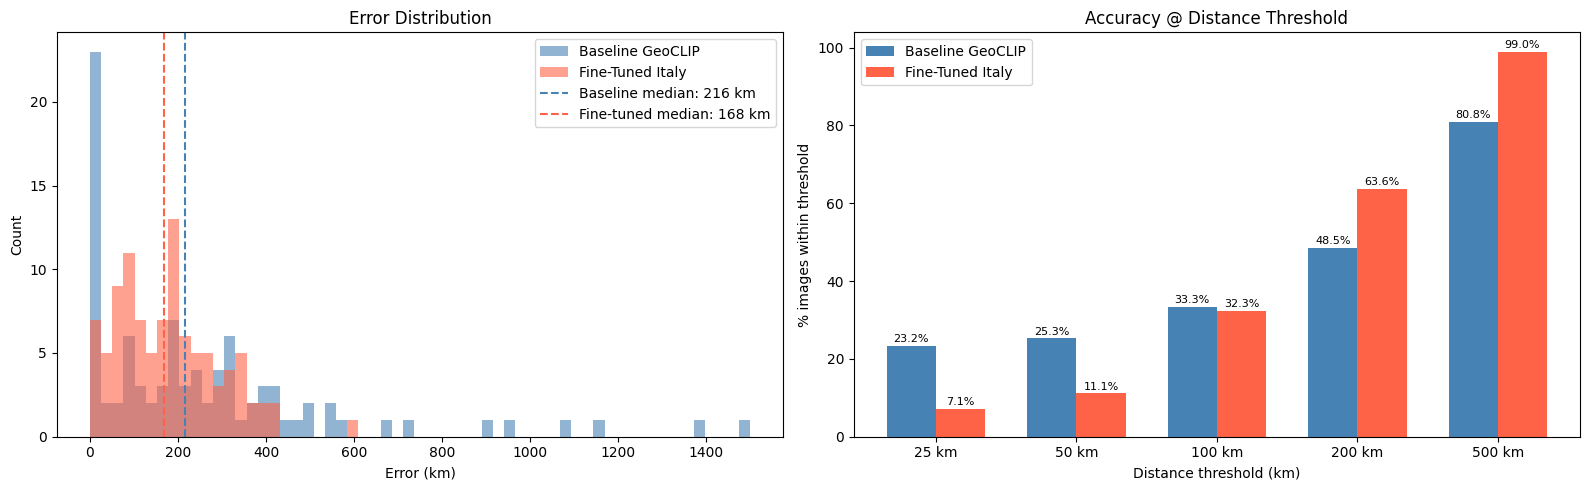

📊 Saved: comparison_error.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Error distribution histogram ---
ax = axes[0]
bins = np.linspace(0, 1500, 60)
ax.hist(baseline_df['error_km'],  bins=bins, alpha=0.6, label='Baseline GeoCLIP',   color='steelblue')
ax.hist(finetuned_df['error_km'], bins=bins, alpha=0.6, label='Fine-Tuned Italy',   color='tomato')
ax.axvline(baseline_df['error_km'].median(),  color='steelblue', linestyle='--', linewidth=1.5,
           label=f"Baseline median: {baseline_df['error_km'].median():.0f} km")
ax.axvline(finetuned_df['error_km'].median(), color='tomato',    linestyle='--', linewidth=1.5,
           label=f"Fine-tuned median: {finetuned_df['error_km'].median():.0f} km")
ax.set_xlabel("Error (km)")
ax.set_ylabel("Count")
ax.set_title("Error Distribution")
ax.legend()

# --- Right: Accuracy @ threshold bar chart ---
ax = axes[1]
thresholds = [25, 50, 100, 200, 500]
b_acc = [np.mean(baseline_df['error_km']  <= t) * 100 for t in thresholds]
f_acc = [np.mean(finetuned_df['error_km'] <= t) * 100 for t in thresholds]

x = np.arange(len(thresholds))
w = 0.35
bars1 = ax.bar(x - w/2, b_acc, w, label='Baseline GeoCLIP', color='steelblue')
bars2 = ax.bar(x + w/2, f_acc, w, label='Fine-Tuned Italy',  color='tomato')
ax.set_xlabel("Distance threshold (km)")
ax.set_ylabel("% images within threshold")
ax.set_title("Accuracy @ Distance Threshold")
ax.set_xticks(x)
ax.set_xticklabels([f"{t} km" for t in thresholds])
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("comparison_error.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: comparison_error.png")


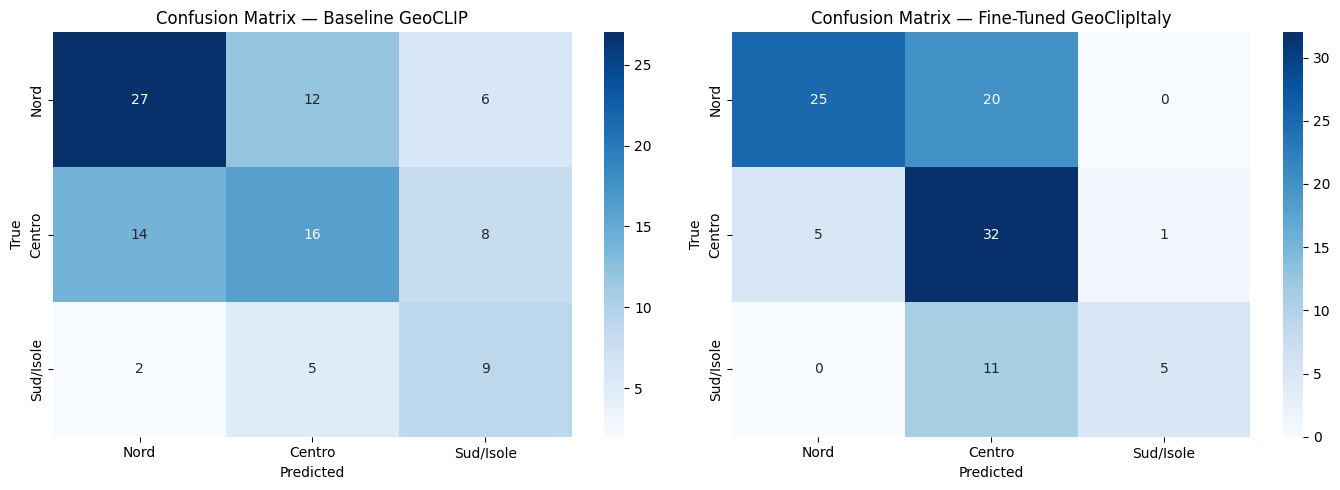


--- Baseline Classification Report ---
              precision    recall  f1-score   support

        Nord      0.628     0.600     0.614        45
      Centro      0.485     0.421     0.451        38
   Sud/Isole      0.391     0.562     0.462        16

    accuracy                          0.525        99
   macro avg      0.501     0.528     0.509        99
weighted avg      0.535     0.525     0.527        99

--- Fine-Tuned Classification Report ---
              precision    recall  f1-score   support

        Nord      0.833     0.556     0.667        45
      Centro      0.508     0.842     0.634        38
   Sud/Isole      0.833     0.312     0.455        16

    accuracy                          0.626        99
   macro avg      0.725     0.570     0.585        99
weighted avg      0.708     0.626     0.620        99



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def macro_region(lat):
    if lat > 44.0:   return "Nord"
    elif lat > 41.5: return "Centro"
    else:            return "Sud/Isole"

labels = ["Nord", "Centro", "Sud/Isole"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [
    (axes[0], baseline_df,  "Baseline GeoCLIP"),
    (axes[1], finetuned_df, "Fine-Tuned GeoClipItaly"),
]:
    true_r = [macro_region(r) for r in df['lat_true']]
    pred_r = [macro_region(r) for r in df['lat_pred']]
    cm = confusion_matrix(true_r, pred_r, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix — {title}')

plt.tight_layout()
plt.savefig("comparison_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Baseline Classification Report ---")
print(classification_report(
    [macro_region(r) for r in baseline_df['lat_true']],
    [macro_region(r) for r in baseline_df['lat_pred']],
    labels=labels, digits=3
))
print("--- Fine-Tuned Classification Report ---")
print(classification_report(
    [macro_region(r) for r in finetuned_df['lat_true']],
    [macro_region(r) for r in finetuned_df['lat_pred']],
    labels=labels, digits=3
))


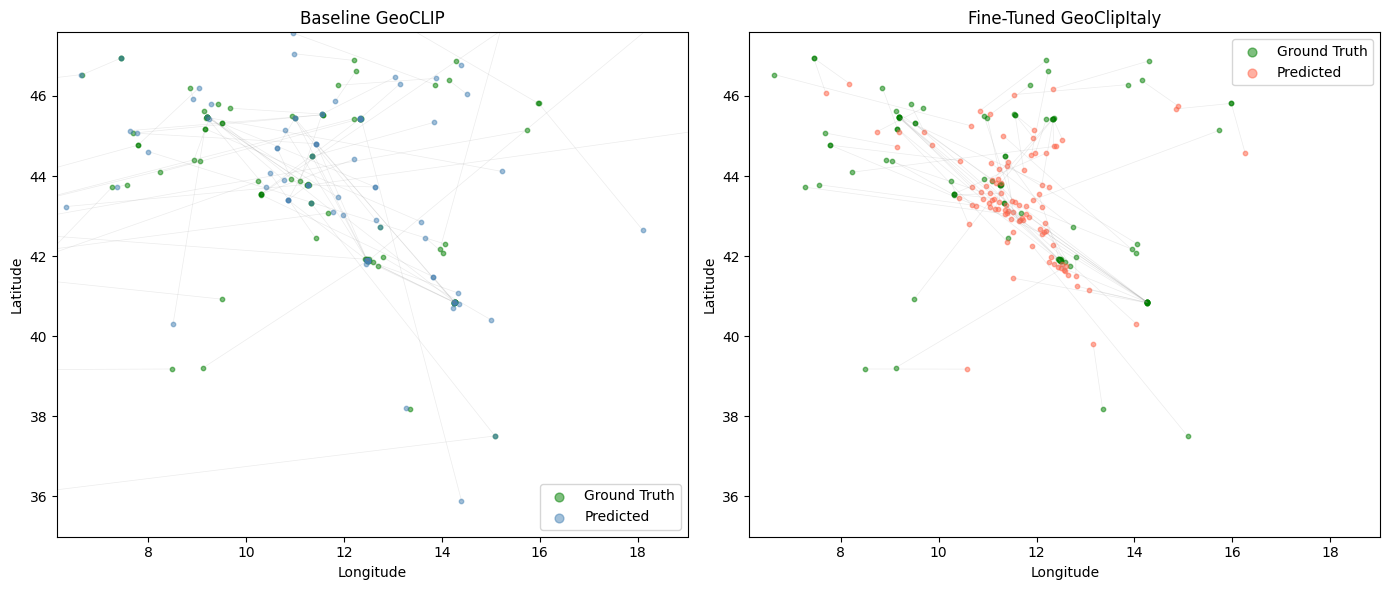

📊 Saved: comparison_scatter.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title, color in [
    (axes[0], baseline_df,  "Baseline GeoCLIP",       "steelblue"),
    (axes[1], finetuned_df, "Fine-Tuned GeoClipItaly", "tomato"),
]:
    ax.scatter(df['lon_true'], df['lat_true'], c='green',  s=10, alpha=0.5, label='Ground Truth')
    ax.scatter(df['lon_pred'], df['lat_pred'], c=color,    s=10, alpha=0.5, label='Predicted')

    # Draw lines between true and predicted
    for _, row in df.iterrows():
        ax.plot([row['lon_true'], row['lon_pred']], [row['lat_true'], row['lat_pred']],
                c='gray', alpha=0.15, linewidth=0.5)

    # Italy bounding box
    ax.set_xlim(MIN_LON - 0.5, MAX_LON + 0.5)
    ax.set_ylim(MIN_LAT - 0.5, MAX_LAT + 0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.legend(markerscale=2)

plt.tight_layout()
plt.savefig("comparison_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved: comparison_scatter.png")


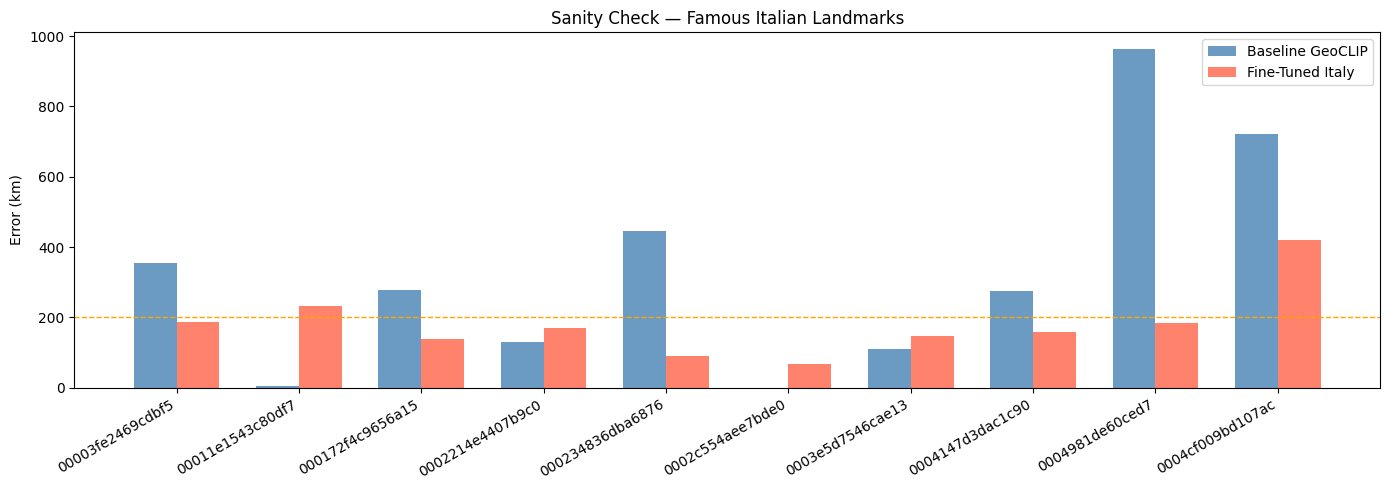

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

names   = [r['name'] for r in sanity_results]
b_errs  = [r['b_err'] for r in sanity_results]
f_errs  = [r['f_err'] for r in sanity_results]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, b_errs, w, label='Baseline GeoCLIP',   color='steelblue', alpha=0.8)
ax.bar(x + w/2, f_errs, w, label='Fine-Tuned Italy',   color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n.split(' (')[0] for n in names], rotation=30, ha='right')
ax.set_ylabel("Error (km)")
ax.set_title("Sanity Check — Famous Italian Landmarks")
ax.legend()
ax.axhline(200, color='orange', linestyle='--', linewidth=1, label='200 km')

plt.tight_layout()
plt.savefig("sanity_check_bars.png", dpi=150, bbox_inches='tight')
plt.show()


## 🗺️ Section 7: Map Visualization

In [ ]:
import folium
from IPython.display import display

# Show N random test images with both model predictions on the same map
N_MAP_SAMPLES = 10

merged = baseline_df.merge(
    finetuned_df[['path', 'lat_pred', 'lon_pred', 'error_km']],
    on='path', suffixes=('_base', '_ft')
).sample(n=min(N_MAP_SAMPLES, len(baseline_df)), random_state=42)

m = folium.Map(location=[42.5, 12.5], zoom_start=6)

for _, row in merged.iterrows():
    t_lat, t_lon = row['lat_true'], row['lon_true']
    b_lat, b_lon = row['lat_pred_base'], row['lon_pred_base']
    f_lat, f_lon = row['lat_pred_ft'],   row['lon_pred_ft']

    # Ground truth (green)
    folium.Marker([t_lat, t_lon],
                  popup=f"Ground Truth",
                  icon=folium.Icon(color='green', icon='home')).add_to(m)

    # Baseline prediction (blue)
    folium.Marker([b_lat, b_lon],
                  popup=f"Baseline: {row['error_km_base']:.0f} km",
                  icon=folium.Icon(color='blue', icon='info-sign')).add_to(m)

    # Fine-tuned prediction (red)
    folium.Marker([f_lat, f_lon],
                  popup=f"Fine-tuned: {row['error_km_ft']:.0f} km",
                  icon=folium.Icon(color='red', icon='star')).add_to(m)

    # Lines
    folium.PolyLine([(t_lat, t_lon), (b_lat, b_lon)],
                    color='blue', weight=1.5, opacity=0.6, dash_array='5').add_to(m)
    folium.PolyLine([(t_lat, t_lon), (f_lat, f_lon)],
                    color='red',  weight=1.5, opacity=0.6).add_to(m)

# Legend
legend = (
    "<div style='position:fixed;bottom:30px;left:30px;z-index:1000;"
    "background:white;padding:10px;border-radius:5px;"
    "border:1px solid grey;font-size:13px'>"
    "<b>Legend</b><br>"
    "&#x1F7E2; Ground Truth<br>"
    "&#x1F535; Baseline GeoCLIP (dashed)<br>"
    "&#x1F534; Fine-Tuned Italy (solid)"
    "</div>"
)
m.get_root().html.add_child(folium.Element(legend))
display(m)
m.save("comparison_map.html")
print("💾 Map saved: comparison_map.html")


💾 Map saved: comparison_map.html


In [ ]:
import folium
from IPython.display import display

m2 = folium.Map(location=[42.5, 12.5], zoom_start=6)

for r in sanity_results:
    t_lat, t_lon = r['lat'],   r['lon']
    b_lat, b_lon = r['b_lat'], r['b_lon']
    f_lat, f_lon = r['f_lat'], r['f_lon']

    folium.Marker([t_lat, t_lon],
                  popup=f"{r['name']} (True)",
                  icon=folium.Icon(color='green', icon='home')).add_to(m2)

    if b_lat:
        folium.Marker([b_lat, b_lon],
                      popup=f"Baseline: {r['b_err']:.0f} km",
                      icon=folium.Icon(color='blue', icon='info-sign')).add_to(m2)
        folium.PolyLine([(t_lat, t_lon), (b_lat, b_lon)],
                        color='blue', weight=1.5, dash_array='5').add_to(m2)

    if f_lat:
        folium.Marker([f_lat, f_lon],
                      popup=f"Fine-tuned: {r['f_err']:.0f} km",
                      icon=folium.Icon(color='red', icon='star')).add_to(m2)
        folium.PolyLine([(t_lat, t_lon), (f_lat, f_lon)],
                        color='red', weight=1.5).add_to(m2)

display(m2)
m2.save("sanity_check_map.html")
print("💾 Map saved: sanity_check_map.html")


💾 Map saved: sanity_check_map.html


## 🎲 Section 8: MC Dropout — Single Image Heatmap (Fine-Tuned Model)

In [ ]:
import os
import folium
import numpy as np
import requests
import torch
from PIL import Image
from folium.plugins import HeatMap
from io import BytesIO
from IPython.display import display

# Change this to any local image path or URL
IMAGE_SOURCE = "/content/venezia.jpg"   # <-- CHANGE THIS

def predict_mc_dropout(model, source, num_samples=50):
    if source.startswith("http"):
        headers = {'User-Agent': 'Mozilla/5.0'}
        r = requests.get(source, headers=headers, timeout=10)
        img = Image.open(BytesIO(r.content)).convert("RGB")
    elif os.path.exists(source):
        img = Image.open(source).convert("RGB")
    else:
        print(f"❌ Not found: {source}")
        return None

    tensor = eval_transform(img).unsqueeze(0).to(device)
    model.eval()
    enable_dropout(model)   # activate dropout only, BN stays frozen

    preds = []
    with torch.no_grad():
        for _ in range(num_samples):
            out = model(tensor).cpu().numpy()[0]
            lat, lon = denorm(out[0], out[1])
            preds.append([lat, lon])

    model.eval()
    return np.array(preds)


def create_heatmap(predictions, title="MC Dropout Heatmap"):
    coords = predictions.tolist()
    avg_lat = np.mean(predictions[:, 0])
    avg_lon = np.mean(predictions[:, 1])

    m = folium.Map(location=[avg_lat, avg_lon], zoom_start=6,
                   tiles="CartoDB dark_matter")

    weighted = [(lat, lon, 1.0 / len(coords)) for lat, lon in coords]
    magma = {
        '0.0': '#932667', '0.2': '#b5367a', '0.4': '#d3466b',
        '0.6': '#f1605d', '0.8': '#fd9668', '1.0': '#fcfdbf'
    }
    HeatMap(weighted, radius=25, blur=15, gradient=magma).add_to(m)

    folium.Marker([avg_lat, avg_lon],
                  popup=f"{title}<br>Lat: {avg_lat:.3f}, Lon: {avg_lon:.3f}",
                  icon=folium.Icon(color='orange', icon='star')).add_to(m)

    for lat, lon in coords:
        folium.CircleMarker([lat, lon], radius=2, color='cyan',
                            fill=True, fill_opacity=0.3).add_to(m)
    return m


print(f"🎲 Running {MC_DROPOUT_RUNS} MC Dropout passes on: {IMAGE_SOURCE}")
mc_preds = predict_mc_dropout(finetuned_model, IMAGE_SOURCE, num_samples=MC_DROPOUT_RUNS)

if mc_preds is not None:
    print(f"   Mean prediction : lat={np.mean(mc_preds[:,0]):.3f}, lon={np.mean(mc_preds[:,1]):.3f}")
    print(f"   Std             : lat={np.std(mc_preds[:,0]):.3f}, lon={np.std(mc_preds[:,1]):.3f}")
    hm = create_heatmap(mc_preds, title="Fine-Tuned Prediction")
    display(hm)
    hm.save("mc_dropout_heatmap.html")
    print("💾 Saved: mc_dropout_heatmap.html")


🎲 Running 50 MC Dropout passes on: /content/venezia.jpg
❌ Not found: /content/venezia.jpg
